In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
dataset=pd.read_csv('Mall_Customers.csv')
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values
data=x.T
print("Data shape",data.shape)

Data shape (2, 200)


In [5]:
#pip install scikit-fuzzy

In [6]:
import skfuzzy as fuzz

In [7]:

n_clusters = 5
m = 1.5
error = 0.005
maxiter = 1000
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(data, c=n_clusters, m=m, error=error, maxiter=maxiter, init=None)

In [8]:
labels = np.argmax(u, axis=0)

In [9]:
print("Cluster Centers:\n", cntr)
print("\nFPC Score:",fpc)

Cluster Centers:
 [[87.61611497 16.9441403 ]
 [55.36848609 49.60307722]
 [25.78362042 79.32358526]
 [86.03563182 82.28914004]
 [26.09199966 19.91306211]]

FPC Score: 0.9153651990473235


In [15]:
newdataset=dataset
newdataset['cluster']=np.argmax(u,axis=0)
membership_df=pd.DataFrame(u.T,columns=[f'cluster_{i}_membership' for i in range(u.shape[0]) ])
newdataset=pd.concat([newdataset,membership_df],axis=1)
newdataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,cluster_0_membership,cluster_1_membership,cluster_2_membership,cluster_3_membership,cluster_4_membership
0,1,Male,19,15,39,4,0.006127,0.066970,0.066952,0.004244,0.855708
1,2,Male,21,15,81,2,0.000161,0.002066,0.996268,0.000555,0.000951
2,3,Female,20,16,6,4,0.003124,0.007225,0.002874,0.000748,0.986029
3,4,Female,23,16,77,2,0.000134,0.001926,0.996620,0.000419,0.000902
4,5,Female,31,17,40,4,0.006471,0.080513,0.074754,0.004587,0.833676
...,...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,3,0.049717,0.046960,0.015147,0.880300,0.007876
196,197,Female,45,126,28,0,0.800085,0.068437,0.012674,0.098627,0.020178
197,198,Male,32,126,74,3,0.098723,0.070796,0.021762,0.795469,0.013251
198,199,Male,32,137,18,0,0.772194,0.078294,0.017669,0.101479,0.030364


In [ ]:
newdataset.to_csv("Clustered_Mall_Customers_fuzzy.csv",index=False)

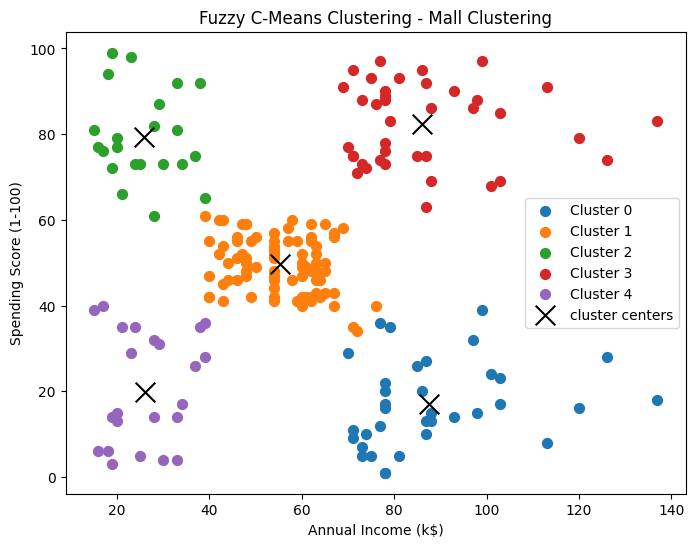

In [12]:
#plt.scatter(x[:,0],x[:,1],c=labels,s=50)
c_labels = np.argmax(u, axis=0)
X=data.T
plt.figure(figsize=(8,6))
for i in range(n_clusters):
    plt.scatter(X[c_labels==i,0],X[c_labels==i,1],s=50,label=f'Cluster {i+1}')
plt.scatter(cntr[:,0],cntr[:,1], color='black',marker='x',s=200,label='cluster centers')
plt.title("Fuzzy C-Means Clustering - Mall Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(loc='best')
plt.show()

In [13]:
import pickle
filename='final_model.sav'
pickle.dump(cntr,open(filename,'wb'))